<a href="https://colab.research.google.com/github/Pentaphone/nn_tests/blob/main/nn_test_1/nn_test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup

In [6]:
# imports
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2 as transforms


# config
train_batch_size = 64
test_batch_size = 64
learning_rate = 1e-3
epochs = 10


# training and test data
image_transform = transforms.Compose([
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True)
])

training_data = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = image_transform
)

test_data = datasets.MNIST(
    root = "data",
    train = False,
    download = True,
    transform = image_transform
)

training_loader = DataLoader(training_data, batch_size=train_batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_batch_size, shuffle=True)


### Data Examples

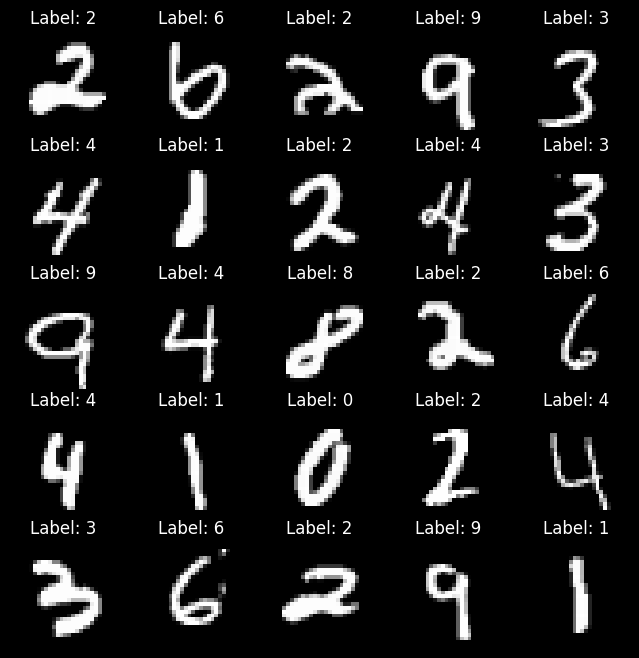

In [7]:
# examples
plt.style.use('dark_background')
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    rand_index = torch.randint(0, len(training_data)-25, (1,)).item()
    image, label = training_data[rand_index+i]
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

### Model

In [8]:
# model
class ConvNeuralNetwork(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.convolution = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

  def forward(self, x):
    x = self.convolution(x)
    output = self.classifier(x)

    return output


def train(dataloader, model, loss_fn, optimizer):
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    output = model(X)
    loss = loss_fn(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{len(dataloader.dataset):>5d}]")


def test(dataloader, model, loss_fn):
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
      for X, y in dataloader:
        output = model(X)
        test_loss += loss_fn(output, y).item()
        pred = output.argmax(1)
        correct += (pred == y).type(torch.float).sum().item()
    test_loss /= len(dataloader)
    correct /= len(dataloader.dataset)

    print(f"\n Test \n Avg loss: {test_loss:>8f}, Accuracy: {(100*correct):>0.1f}% \n")


model = ConvNeuralNetwork()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


test(test_loader, model, loss_fn)

for epoch in range(epochs):
  print(f"Eppoch {epoch+1}/{epochs}")
  train(training_loader, model, loss_fn, optimizer)
  test(test_loader, model, loss_fn)


 Test 
 Avg loss: 2.307226, Accuracy: 9.6% 

Eppoch 1/10
loss: 2.299384  [    0/60000]
loss: 2.301576  [ 6400/60000]
loss: 2.292147  [12800/60000]
loss: 2.293501  [19200/60000]
loss: 2.289201  [25600/60000]
loss: 2.278919  [32000/60000]
loss: 2.286576  [38400/60000]
loss: 2.275919  [44800/60000]
loss: 2.275711  [51200/60000]
loss: 2.264888  [57600/60000]

 Test 
 Avg loss: 2.257786, Accuracy: 35.0% 

Eppoch 2/10
loss: 2.257776  [    0/60000]
loss: 2.266106  [ 6400/60000]
loss: 2.247986  [12800/60000]
loss: 2.248120  [19200/60000]
loss: 2.232515  [25600/60000]
loss: 2.207131  [32000/60000]
loss: 2.210259  [38400/60000]
loss: 2.193676  [44800/60000]
loss: 2.160495  [51200/60000]
loss: 2.134356  [57600/60000]

 Test 
 Avg loss: 2.141448, Accuracy: 59.1% 

Eppoch 3/10
loss: 2.142422  [    0/60000]
loss: 2.117878  [ 6400/60000]
loss: 2.099827  [12800/60000]
loss: 2.072124  [19200/60000]
loss: 1.993052  [25600/60000]
loss: 2.035982  [32000/60000]
loss: 1.918607  [38400/60000]
loss: 1.865433

In [28]:
def predict(image, probabilities=False):
  model.eval()
  with torch.no_grad():
    output = model(image.unsqueeze(0))

  probs_tensor = torch.softmax(output, dim=1)
  if probabilities:
    return probs_tensor
  else:
    pred = torch.argmax(probs_tensor)
    return pred

torch.save(model.state_dict(), 'model_weights.pth')
torch.save(model, 'model.pth')

### Prediction Example

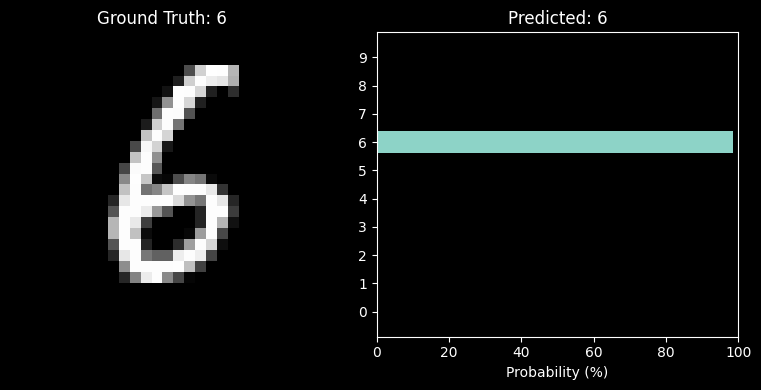

In [37]:
plt.style.use('dark_background')
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
rand_index = torch.randint(0, len(training_data), (1,)).item()
image, label = training_data[rand_index]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Ground Truth: {label}")
plt.axis("off")

pred = predict(image)
probabilities = predict(image, probabilities=True)

plt.subplot(1, 2, 2)
class_labels = [str(i) for i in range(10)]
plt.barh(class_labels, probabilities.squeeze().numpy() * 100)
plt.title(f"Predicted: {pred.item()}")
plt.xlabel("Probability (%)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()